In [143]:
from pyteomics import fasta
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [144]:
diann_results = pd.read_parquet("/home/robbe/MuMDIA/DIA-NN_output/ecoli/report.parquet")
diann_results["RT"] = diann_results["RT"].astype(float) * 60

In [145]:
# Read in all the fasta files
fasta_dict = {}

# Read in all the fasta files from /home/robbe/MuMDIA/results/config_playing/temp/
for fasta_path in glob.glob("/home/robbe/MuMDIA/results/config_playing/temp/*/*.fasta"):
    with open(fasta_path) as f:
        fasta_dict[fasta_path] = list(
            fasta.read(f)
        )  # Convert to list to store the data

In [146]:
len(fasta_dict.keys())

1

In [147]:
diann_results

,Run.Index,Run,Channel,Precursor.Id,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,Proteotypic,...,Translated.Q.Value,Channel.Q.Value,PG.Q.Value,PG.PEP,GG.Q.Value,Protein.Q.Value,Global.PG.Q.Value,Lib.PG.Q.Value,Best.Fr.Mz,Best.Fr.Mz.Delta
0,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAEIAVK2,AAAAEIAVK,AAAAEIAVK,2,10,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,317.218323,0.000641
1,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAPVTGPLADDPIQETITFDDFAK3,AAAAPVTGPLADDPIQETITFDDFAK,AAAAPVTGPLADDPIQETITFDDFAK,3,58,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,214.118622,0.001190
2,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAVLAK1,AAAAVLAK,AAAAVLAK,1,72,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,384.224152,-0.000183
3,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADLISR2,AAADLISR,AAADLISR,2,107,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,603.346069,-0.000244
4,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADVQLR2,AAADVQLR,AAADVQLR,2,116,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,701.394043,0.001038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13971,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYLNAGVPIEIK2,YYLNAGVPIEIK,YYLNAGVPIEIK,2,712276,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,599.376282,0.000000
13972,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPAEDAK2,YYPAEDAK,YYPAEDAK,2,712352,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,315.658295,0.000977
13973,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPGSPLIAR2,YYPGSPLIAR,YYPGSPLIAR,2,712362,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,810.483215,0.007996
13974,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYQGTPSPVK2,YYQGTPSPVK,YYQGTPSPVK,2,712461,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,527.318787,0.000122


In [148]:
def check_diann_id_presence_in_fasta(diann_results, fasta_dict):
    correct_matches_num = 0
    incorrect_matches_num = 0
    not_found_num = 0
    incorrect_matches = []
    not_found_matches = []

    for index, row in diann_results.iterrows():
        peptide = row["Stripped.Sequence"]
        RT = row["RT"]

        # First, find all FASTA files that contain this peptide
        found_in_fastas = []
        for fasta_path, fasta_content in fasta_dict.items():
            for entry in fasta_content:
                if peptide == entry.sequence:
                    found_in_fastas.append(fasta_path)
                    break  # Found in this FASTA, no need to check other entries

        if not found_in_fastas:
            # Peptide not found in any FASTA file
            print(f"Peptide {peptide} NOT FOUND in any FASTA file.")
            not_found_num += 1
            not_found_matches.append((peptide, RT))
            continue

        # Check if RT matches any of the FASTA files where peptide was found
        found_matching = False
        matching_fasta = None
        incorrect_fasta = None

        for fasta_path in found_in_fastas:
            RT_bounds = fasta_path.split("/")[7].split("_")[1:3]
            RT_start = float(RT_bounds[0])
            RT_end = float(RT_bounds[1])

            if RT_start <= RT <= RT_end:
                found_matching = True
                matching_fasta = fasta_path
                break
            else:
                incorrect_fasta = fasta_path  # Keep track of one incorrect match

        if found_matching:
            print(f"{peptide} found in {matching_fasta.split('/')[-2]}: CORRECT")
            correct_matches_num += 1
        else:
            print(
                f"{peptide} found in FASTA file(s) but RT does not match any bounds: INCORRECT"
            )
            print(
                f"  Found in {len(found_in_fastas)} FASTA(s): {[f.split('/')[-2] for f in found_in_fastas]}"
            )
            incorrect_matches_num += 1
            # Find the FASTA where the bounds are closest to the observed RT
            min_distance = float("inf")
            closest_fasta = None
            for fasta_path in found_in_fastas:
                RT_bounds = fasta_path.split("/")[7].split("_")[1:3]
                RT_start = float(RT_bounds[0])
                RT_end = float(RT_bounds[1])
                # Distance to closest bound
                if RT < RT_start:
                    distance = RT_start - RT
                elif RT > RT_end:
                    distance = RT - RT_end
                else:
                    distance = 0  # Shouldn't happen for incorrect matches
                if distance < min_distance:
                    min_distance = distance
                    closest_fasta = fasta_path
            incorrect_matches.append((peptide, RT, closest_fasta))

    print("\n" * 2)
    print("Summary:")
    print(f"Sequences found in matching FASTA: {correct_matches_num}")
    print(f"Sequences found in non-matching FASTA: {incorrect_matches_num}")
    print(f"Sequences not found in any FASTA: {not_found_num}")
    print()

    return incorrect_matches, not_found_matches

In [149]:
incorrect_matches, not_found_matches = check_diann_id_presence_in_fasta(
    diann_results, fasta_dict
)

AAAAEIAVK found in part_0.0_13829.432373046875: CORRECT
AAAAPVTGPLADDPIQETITFDDFAK found in part_0.0_13829.432373046875: CORRECT
AAAAVLAK found in part_0.0_13829.432373046875: CORRECT
AAADLISR found in part_0.0_13829.432373046875: CORRECT
AAADVQLR found in part_0.0_13829.432373046875: CORRECT
AAAEADDIFGELSSGK found in part_0.0_13829.432373046875: CORRECT
AAAESSIQVK found in part_0.0_13829.432373046875: CORRECT
AAAEVGAPFIEIHTGCYADAK found in part_0.0_13829.432373046875: CORRECT
AAAFEGELIPASQIDR found in part_0.0_13829.432373046875: CORRECT
AAAFEGELIPASQIDR found in part_0.0_13829.432373046875: CORRECT
AAAGISETLLR found in part_0.0_13829.432373046875: CORRECT
AAAIAYAR found in part_0.0_13829.432373046875: CORRECT
AAAICAER found in part_0.0_13829.432373046875: CORRECT
AAALAAADAR found in part_0.0_13829.432373046875: CORRECT
AAAPAFSEESIR found in part_0.0_13829.432373046875: CORRECT
AAAQLQQGLADTSDENLK found in part_0.0_13829.432373046875: CORRECT
AAASHLVR found in part_0.0_13829.4323730468

In [134]:
def plot_RT_error(incorrect_matches):
    # Plot the Observed RT versus the bounds in which the peptide was included in the fasta
    if not incorrect_matches:
        print("No incorrect matches to plot")
        return

    RTs = [match[1] for match in incorrect_matches]
    bounds = [
        (match[2].split("/")[7].split("_")[1], match[2].split("/")[7].split("_")[2])
        for match in incorrect_matches
    ]

    plt.figure(figsize=(12, 8))

    # Use only a sample of 100 incorrect matches for plotting
    sample_indices = range(min(100, len(incorrect_matches)))
    RTs_sample = [RTs[i] for i in sample_indices]
    bounds_sample = [bounds[i] for i in sample_indices]

    for i, (rt, (bound_start, bound_end)) in enumerate(zip(RTs_sample, bounds_sample)):
        bound_start = float(bound_start)
        bound_end = float(bound_end)

        # Plot bounds as horizontal lines
        plt.plot(
            [bound_start, bound_end],
            [i, i],
            color="red",
            linewidth=3,
            label="RT bounds" if i == 0 else "",
        )

        # Plot vertical lines at bound start and end
        plt.plot(
            [bound_start, bound_start],
            [i - 0.2, i + 0.2],
            color="red",
            linewidth=2,
            alpha=0.7,
        )
        plt.plot(
            [bound_end, bound_end],
            [i - 0.2, i + 0.2],
            color="red",
            linewidth=2,
            alpha=0.7,
        )

        # Plot observed RT as blue dot
        plt.scatter(
            rt, i, color="blue", s=50, zorder=5, label="Observed RT" if i == 0 else ""
        )

        # Add connecting line to show distance to closest bound
        if rt < bound_start:
            plt.plot(
                [rt, bound_start],
                [i, i],
                color="orange",
                linewidth=2,
                linestyle="--",
                alpha=0.7,
                label="Distance to bound" if i == 0 else "",
            )
        elif rt > bound_end:
            plt.plot(
                [rt, bound_end],
                [i, i],
                color="orange",
                linewidth=2,
                linestyle="--",
                alpha=0.7,
            )

    plt.ylabel("Peptide index")
    plt.xlabel("Retention Time (RT)")
    plt.title(
        f"Observed RTs of DIA-NN ids that are not present in vectorized FASTA of that RT region vs closest distance to RT region in which it is included in FASTA ({len(incorrect_matches)} peptides)"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print some statistics
    distances = []
    for rt, (bound_start, bound_end) in zip(RTs, bounds):
        bound_start = float(bound_start)
        bound_end = float(bound_end)
        if rt < bound_start:
            distances.append(bound_start - rt)
        elif rt > bound_end:
            distances.append(rt - bound_end)
        else:
            distances.append(0)  # This shouldn't happen for incorrect matches

    if distances:
        print(f"Average distance from bounds: {sum(distances)/len(distances):.2f} s")
        print(f"Maximum distance from bounds: {max(distances):.2f} s")
        print(f"Minimum distance from bounds: {min(distances):.2f} s")

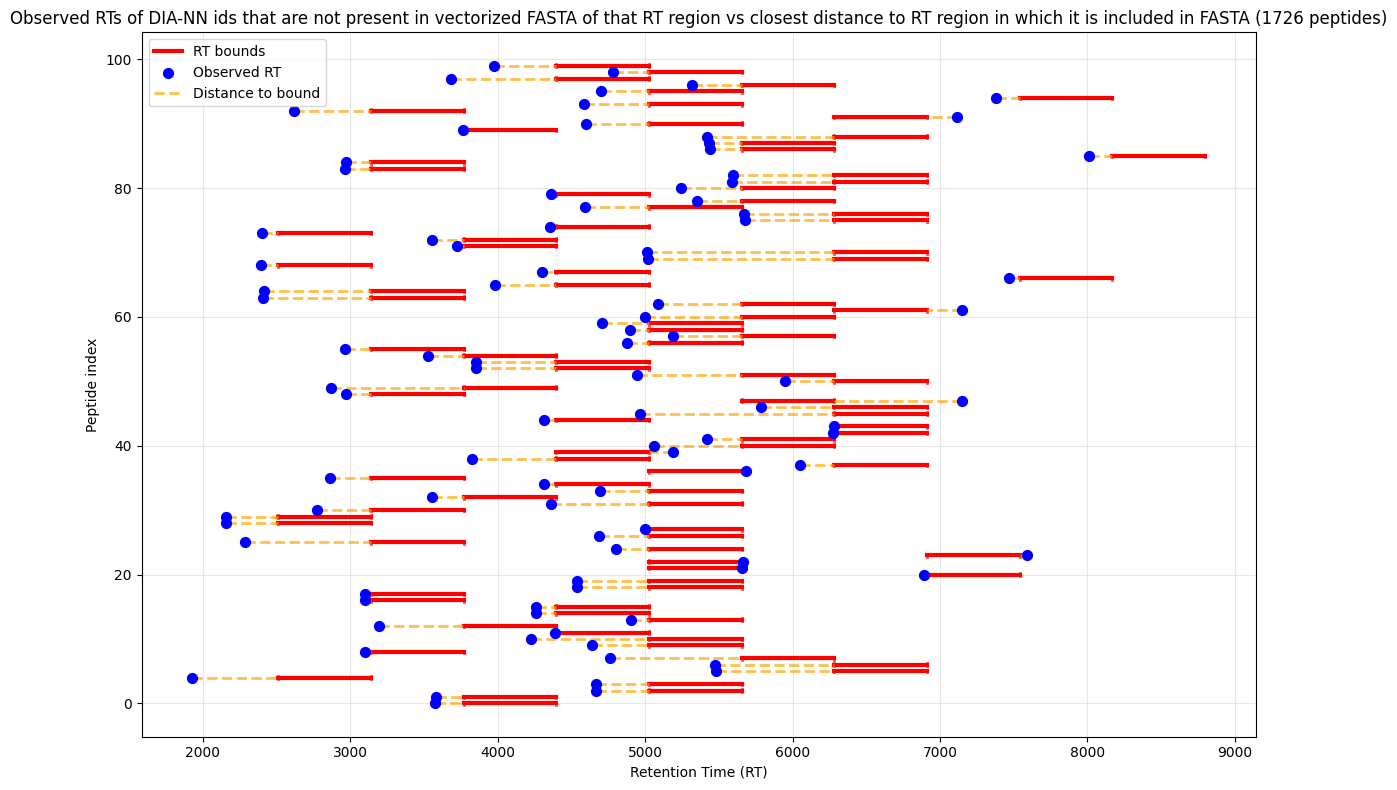

Average distance from bounds: 321.53 s
Maximum distance from bounds: 1585.11 s
Minimum distance from bounds: 0.01 s


In [135]:
plot_RT_error(incorrect_matches)

In [133]:
incorrect_matches

[('AAATQEMTLVDTPNAK',
  3578.290328979492,
  '/home/robbe/MuMDIA/results/config_playing/temp/part_3770.325164794921_4398.712692260741/vectorized_output.fasta'),
 ('AAATQEMTLVDTPNAK',
  3579.8902130126953,
  '/home/robbe/MuMDIA/results/config_playing/temp/part_3770.325164794921_4398.712692260741/vectorized_output.fasta'),
 ('AAEIIHIGQAIMEQK',
  4670.662536621094,
  '/home/robbe/MuMDIA/results/config_playing/temp/part_5027.100219726562_5655.487747192382/vectorized_output.fasta'),
 ('AAEIIHIGQAIMEQK',
  4669.259948730469,
  '/home/robbe/MuMDIA/results/config_playing/temp/part_5027.100219726562_5655.487747192382/vectorized_output.fasta'),
 ('AAFNQMVQGHK',
  1929.9845123291016,
  '/home/robbe/MuMDIA/results/config_playing/temp/part_2513.5501098632803_3141.9376373291007/vectorized_output.fasta'),
 ('AAGAELVGMEDLADQIK',
  5480.667572021484,
  '/home/robbe/MuMDIA/results/config_playing/temp/part_6283.875274658202_6912.2628021240225/vectorized_output.fasta'),
 ('AAGAELVGMEDLADQIK',
  5473.36532